# 数据预处理

## Garbage In, Garbage out

在前面课程中，我们一起探索了机器学习的类型，推导了线性回归的公式，并亲手实现了梯度下降算法。你可能已经注意到，演示时使用的数据都非常干净：全是数字、没有缺失、量纲统一。

但在真实世界中，数据往往充满各种问题：

- 存在缺失值和异常值
- 包含文本、类别等非数值类型
- 量纲差异巨大（房价是百万级，房间数是个位数）

在算法界，有一句至理名言：

> "Garbage In, Garbage Out."（垃圾进，垃圾出）

因此，训练模型之前必须先进行数据预处理（Data Preprocessing）。本节课我们将学习如何把"脏数据"转化为模型可直接使用的高质量数据，并掌握常用的数据预处理工具：Pandas、Matplotlib、Seaborn 与 scikit-learn。

## 零、准备环境与数据

在开始之前，我们先引入数据处理中的四个常用工具

| **工具**               | **用途**                                               |
| ---------------------- | ------------------------------------------------------ |
| Pandas                 | 表格数据处理的瑞士军刀，提供 DataFrame 等核心数据结构  |
| Matplotlib             | Python 最基础的数据可视化库                            |
| Seaborn                | 基于 Matplotlib 的高级可视化库，语法更简洁、图表更美观 |
| Scikit-Learn (sklearn) | 机器学习标准库，包含丰富的预处理工具和常用算法实现     |

本节以经典的 Titanic（泰坦尼克号）生存预测数据集为例，目标是根据乘客的年龄、性别、舱位等信息，预测他们是否生还。

> 数据来源说明：Seaborn 内置了 Titanic 数据集，但已做过部分预处理。为了完整演示预处理流程，我们从[网络地址](https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv)下载原始数据。


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置绘图风格
sns.set_style("whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans'] # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 从网络读取泰坦尼克号数据集
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# 查看数据概览
print("数据集形状:", df.shape)
print("\n前5行数据:")
display(df.head())

print("\n数据类型与缺失值情况:")
print(df.info())

数据集形状: (891, 12)

前5行数据:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



数据类型与缺失值情况:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


观察 `df.info()` 的输出会发现 `Age`（年龄）、`Cabin`（客舱号）和 `Embarked`（登船港口）存在缺失值，且包含文本类型的列，这正是我们需要处理的“脏数据”。

## 一、数据集划分

很多同学拿到数据后，第一反应就是立刻开始清洗和变换。但正确的做法是先划分数据集，再做预处理。机器学习中，通常将数据集划分为三个部分：

| **数据集** | **占比** | **用途**                                 |
| ---------- | -------- | ---------------------------------------- |
| 训练集     | 60%–80%  | 训练模型，学习数据中的规律               |
| 验证集     | 10%–20%  | 调整超参数，评估模型在未见过数据上的表现 |
| 测试集     | 10%–20%  | 模拟真实世界数据，最终评估模型泛化能力   |

![](https://cdn.nlark.com/yuque/0/2025/png/87727/1744531773720-122478ef-3541-4790-8e1a-fc1117aa72c0.png?x-oss-process=image%2Fformat%2Cwebp)

如果先对全量数据做填充、缩放，再划分数据集，测试集的统计信息（如均值、最大值）就会泄露到训练过程中，这就是数据泄露（Data Leakage）。好比学生在考试前偷看了答案，成绩虚高，实际能力却没提升。

> 原则：所有 `fit` 操作只在训练集上进行，测试集只做 `transform`。

`sklearn`提供了方便的数据划分工具，为了简单我们可以只划分训练集和测试集


In [2]:
from sklearn.model_selection import train_test_split

# 定义特征 X 和目标标签 y (Survived)
X = df.drop('Survived', axis=1)
y = df['Survived']

# 划分训练集和测试集 (80% 训练, 20% 测试)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,       # 固定随机种子，保证可复现
    stratify=y             # 分层抽样，保持正负样本比例一致
)

print(f"训练集: {X_train.shape[0]} 样本")
print(f"测试集: {X_test.shape[0]} 样本")
print(f"\n训练集存活率: {y_train.mean():.2%}")
print(f"测试集存活率: {y_test.mean():.2%}")

训练集: 712 样本
测试集: 179 样本

训练集存活率: 38.34%
测试集存活率: 38.55%


原始数据中存活率约为 38%。如果完全随机划分，训练集和测试集的存活率可能出现较大偏差。设置 stratify=y 后，sklearn 会确保两者中 y=0 和 y=1 的比例与原始数据保持一致。

接下来的所有探索和规则制定（EDA、计算均值等）都必须只在 `X_train` 上进行！

## 二、数据探索分析（EDA）

当我们拿到一份陌生数据时，并不清楚哪些列有问题、需要什么处理。EDA（Exploratory Data Analysis，探索性数据分析） 就像是给数据做一次全面体检——通过统计指标和可视化图表，直观地发现数据中的问题和规律，为后续预处理提供依据。

### 基本信息

可以使用 `.info()`方法查看数据集的数据类型和缺失情况


In [3]:
# 查看训练集数据类型和缺失情况
X_train.info()

<class 'pandas.DataFrame'>
Index: 712 entries, 692 to 507
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Pclass       712 non-null    int64  
 2   Name         712 non-null    str    
 3   Sex          712 non-null    str    
 4   Age          575 non-null    float64
 5   SibSp        712 non-null    int64  
 6   Parch        712 non-null    int64  
 7   Ticket       712 non-null    str    
 8   Fare         712 non-null    float64
 9   Cabin        160 non-null    str    
 10  Embarked     710 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 66.8 KB


也可以看缺失比例：


In [5]:
# 缺失值统计
missing = X_train.isnull().sum()
missing_pct = (missing / len(X_train) * 100).round(1)
pd.DataFrame({"缺失数": missing, "缺失率%": missing_pct}).query("缺失数 > 0")

,缺失数,缺失率%
Age,137,19.2
Cabin,552,77.5
Embarked,2,0.3


可以看到：

- `Cabin` 缺失 77.4%——缺失极多，信息量匮乏
- `Age` 缺失 20.1%——有明显缺失，需要填充
- `Embarked` 缺失 0.3%——仅 2 条记录缺失

### 数值特征统计


In [6]:
X_train.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,712.000000,712.000000,575.000000,712.000000,712.000000,712.000000
mean,444.405899,2.308989,29.807687,0.492978,0.390449,31.819826
std,257.465527,0.833563,14.485211,1.060720,0.838134,48.059104
min,1.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,222.750000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,439.500000,3.000000,28.500000,0.000000,0.000000,14.454200
75%,667.250000,3.000000,39.000000,1.000000,0.000000,31.000000
max,891.000000,3.000000,80.000000,8.000000,6.000000,512.329200


注意 Fare 最大 512，最小 0，量纲差异巨大，后面需要缩放。

### 数据可视化

可以使用 Matplotlib 和 seaborn 对数据进行可视化，看出更多端倪


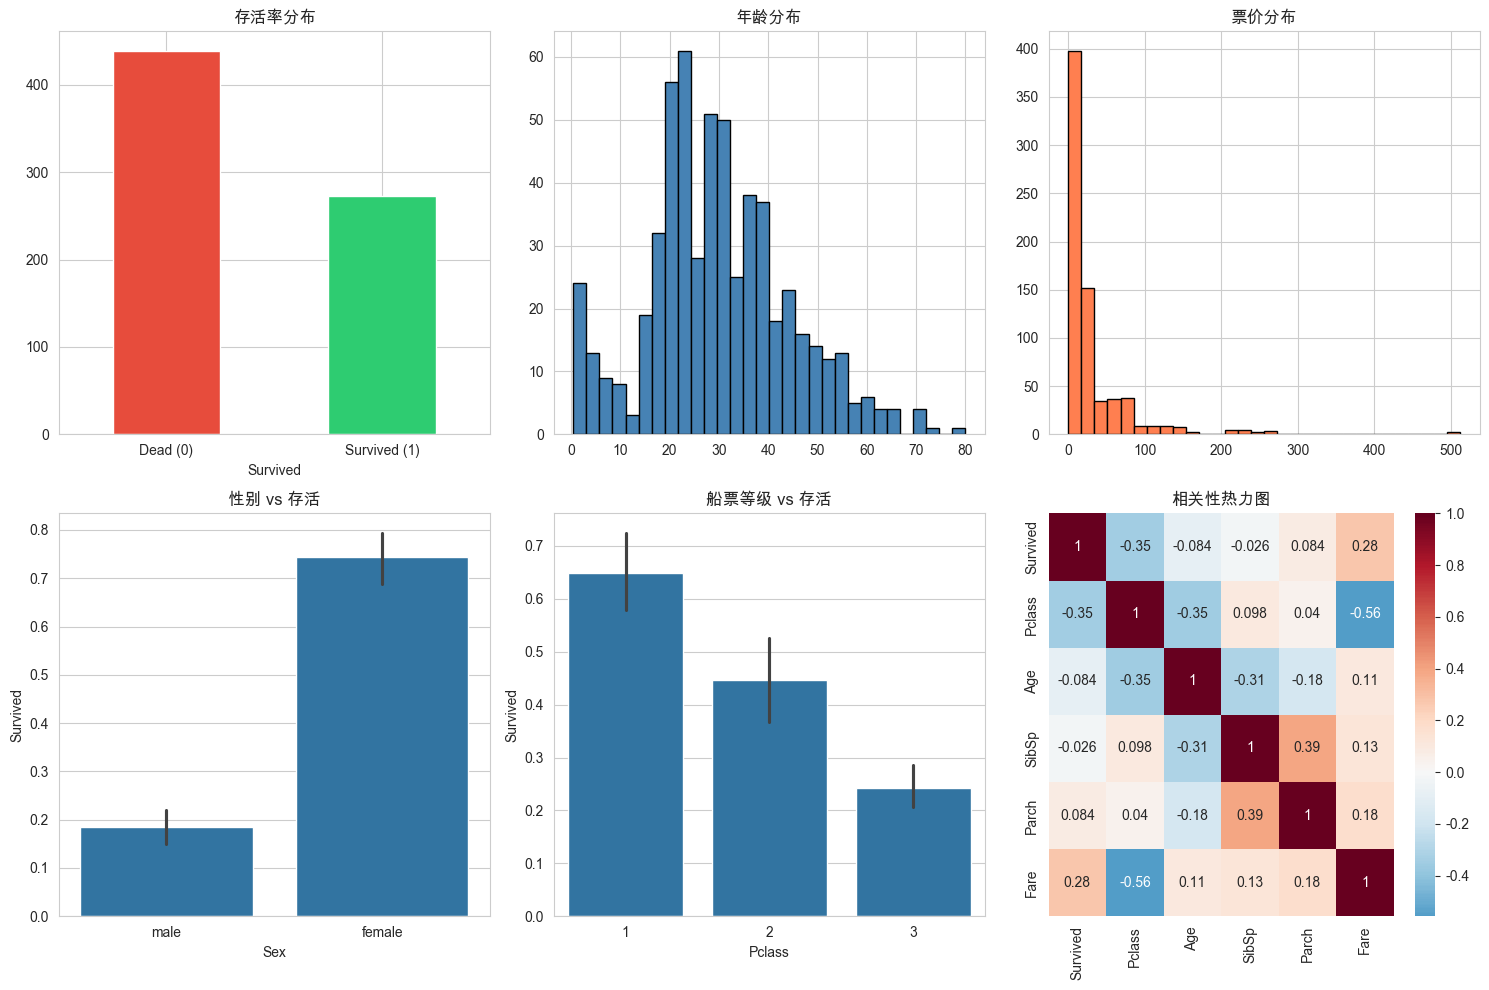

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. 存活率分布
y_train.value_counts().plot.bar(ax=axes[0,0], color=['#e74c3c','#2ecc71'])
axes[0,0].set_title('存活率分布')
axes[0,0].set_xticklabels(['Dead (0)', 'Survived (1)'], rotation=0)

# 2. 年龄分布
X_train['Age'].hist(bins=30, ax=axes[0,1], color='steelblue', edgecolor='black')
axes[0,1].set_title('年龄分布')

# 3. 票价分布
X_train['Fare'].hist(bins=30, ax=axes[0,2], color='coral', edgecolor='black')
axes[0,2].set_title('票价分布')

# 4. 性别 vs 存活
train_data = X_train.copy()
train_data['Survived'] = y_train
sns.barplot(x='Sex', y='Survived', data=train_data, ax=axes[1,0])
axes[1,0].set_title('性别 vs 存活')

# 5. 船票等级 vs 存活
sns.barplot(x='Pclass', y='Survived', data=train_data, ax=axes[1,1])
axes[1,1].set_title('船票等级 vs 存活')

# 6. 相关性热力图
numeric_cols = train_data[['Survived','Pclass','Age','SibSp','Parch','Fare']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='RdBu_r', center=0, ax=axes[1,2])
axes[1,2].set_title('相关性热力图')

plt.tight_layout()
plt.show()

### EDA 关键发现

通过以上可视化，我们得出六条关键发现，它们将直接指导后续的预处理策略：

| **发现**                                   | **对应处理**                                |
| ------------------------------------------ | ------------------------------------------- |
| 女性存活率远高于男性（~74% vs ~19%）       | Sex 是强特征，需编码为数值                  |
| 一等舱存活率最高（~63%）                   | Pclass 是强特征，考虑保留或独热编码         |
| Age 缺失约 20%                             | 需要填充，分布略偏态，选用中位数            |
| Cabin 缺失 77%                             | 直接填充意义不大，考虑转化为"有/无客舱信息" |
| Fare 严重右偏（均值 > 中位数，长尾分布）   | 可能需要对数变换或截断处理                  |
| PassengerId、Name、Ticket 对预测无直接帮助 | 考虑删除，或从 Name 中提取有用信息          |

## 三、数据清洗

数据清洗的核心环节通常涵盖重复值剔除、缺失值填补以及异常值检测与处理。

### 处理重复值

对于数据中重复的行删除即可


In [8]:
# 检查重复行
duplicates = X_train.duplicated().sum()
print(f"重复行数: {duplicates}")

# 如果有重复行
if duplicates > 0:
    X_train = X_train.drop_duplicates()
    y_train = y_train[X_train.index]  # 保持 y 与 X 同步

重复行数: 0


`X_train`和 `y_train`是靠索引（Index）对齐的，当你从 `X_train` 删除了某一行，`y_train` 也要删除对应的行。

### 处理缺失值

当数据集中出现缺失值时，处理策略需根据缺失比例及特征类型灵活选择：

**按缺失比例决定删除策略：**

- 缺失极低（< 5%） 且为随机缺失 → 直接删除对应样本行
- 缺失极高（> 70%） → 该特征信息量匮乏，通常直接删除整列

**按特征类型选择填充方法：**

- **数值型特征**：用均值或中位数填充。均值适用于正态分布且无异常值的场景；中位数对极端值不敏感，在数据偏态或存在异常值时更加稳健
- **类别型特征**：用众数填充，或新增 `"Unknown"` 类别。众数填充适合低缺失率场景；将缺失独立标记为 `"Unknown"` 则能保留缺失本身可能蕴含的业务信息

sklearn 提供了 SimpleImputer 工具类处理缺失值，它可以扫描数据列，发现空缺后，根据设定的 strategy，自动计算一个值填进去

> 1. 初始化时设置 `strategy`
> 2. 在训练集上调用 `.fit()`算出均值/中位数/众数，保存在对象内部
> 3. 在测试集/新数据上调用 `.transform()`：将保存的数据进行填充


In [9]:
from sklearn.impute import SimpleImputer

# ── Age: 中位数填充（因为 Age 分布略有偏态）──
age_imputer = SimpleImputer(strategy='median')
# fit 只用训练集！
age_imputer.fit(X_train[['Age']])
print(f"训练集 Age 中位数: {age_imputer.statistics_[0]}")  # 28.0

X_train['Age'] = age_imputer.transform(X_train[['Age']]).ravel()
X_test['Age']  = age_imputer.transform(X_test[['Age']]).ravel()  # 用训练集的中位数！

# ── Embarked: 众数填充（只缺 2 个）──
embarked_imputer = SimpleImputer(strategy='most_frequent')
embarked_imputer.fit(X_train[['Embarked']])
print(f"训练集 Embarked 众数: {embarked_imputer.statistics_[0]}")  # 'S'

X_train['Embarked'] = embarked_imputer.transform(X_train[['Embarked']]).ravel()
X_test['Embarked']  = embarked_imputer.transform(X_test[['Embarked']]).ravel()

# ── Cabin: 缺失 77%，先转化为"有无客舱信息"，再删除原列 ──
X_train['HasCabin'] = X_train['Cabin'].notna().astype(int)
X_test['HasCabin']  = X_test['Cabin'].notna().astype(int)

X_train.drop(columns=['Cabin'], inplace=True)
X_test.drop(columns=['Cabin'], inplace=True)

# 验证
print("\n处理后缺失值:")
print(X_train.isnull().sum())

训练集 Age 中位数: 28.5
训练集 Embarked 众数: S

处理后缺失值:
PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
HasCabin       0
dtype: int64


### 处理异常值

异常值（Outliers）是指数据中显著偏离其他观测值的极端值，它们可能是由于测量误差、数据录入错误或真实的极端情况产生的。可以使用箱线图检测异常值


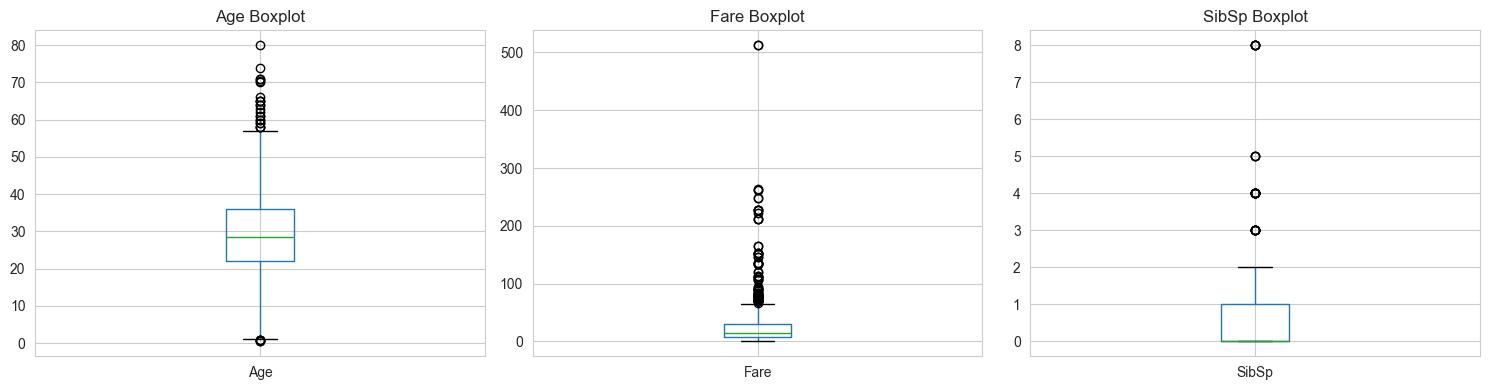

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(['Age', 'Fare', 'SibSp']):
    X_train.boxplot(column=col, ax=axes[i])
    axes[i].set_title(f'{col} Boxplot')

plt.tight_layout()
plt.show()

- **Age (年龄)**:
  - 大部分乘客集中在 20-40 岁之间（箱体部分）。
  - 但在 60-80 岁之间有很多离群点。这说明船上有不少高龄乘客，虽然人数少，但他们是真实存在的，不是数据错误。
- **Fare (票价)**:
  - **极度右偏**。绝大多数人的票价非常低（箱体被压扁在底部，接近 0-50 美元）。
  - 但是有极少数人的票价高得离谱，超过 500 美元！这些可能是一等舱乘客。
  - **对模型的影响**：这种巨大的差异会让模型难以训练，如果不处理（比如取对数 `log` 或分箱），模型可能会过度关注这几个高价票的人，而忽略了普通大众。
- **SibSp (兄弟姐妹/配偶数)**:
  - 大部分人都是 0 或 1，独自旅行或夫妻同行。
  - 但也有一些大家庭，带着 3、4、5 甚至 8 个亲属，这也是真实的异常值。

我们使用统计学方法（IQR）识别并处理票价（Fare）中的极端异常值，防止它们干扰机器学习模型的训练。不必直接删除这些异常数据，采用截断的策略，将过高的票价强行拉回到合理范围内即可。


In [11]:
# 用 IQR 方法检测
def detect_outliers_iqr(data, column, factor=1.5):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = max(0, Q1 - factor * IQR)
    upper = Q3 + factor * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    print(f"{column}: Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}")
    print(f"  合理范围: [{lower:.1f}, {upper:.1f}]")
    print(f"  异常值数量: {len(outliers)} ({len(outliers)/len(data):.1%})")
    return lower, upper

lower, upper = detect_outliers_iqr(X_train, 'Fare')

# 对于 Fare，我们选择截断而非删除
# 因为高票价可能是真实的，头等舱确实很贵
X_train['Fare'] = X_train['Fare'].clip(lower=lower, upper=upper)
X_test['Fare']  = X_test['Fare'].clip(lower=lower, upper=upper)

Fare: Q1=7.9, Q3=31.0, IQR=23.1
  合理范围: [0.0, 65.7]
  异常值数量: 91 (12.8%)


## 四、特征编码

由于大多数机器学习算法仅支持数值型输入，因此必须将数据集中文本数据通过编码技术映射为数值形式，以便模型能够进行数学运算。针对不同场景有三种常见的特征编码方法：序数编码（Ordinal Encoding）、独热编码（One-Hot Encoding）和标签编码（Label Encoding）。

这三种编码方式的核心区别在于是否保留了类别的顺序信息以及是否引入了虚假的数值大小关系。选择哪种方式，取决于你的数据特征类型和你使用的模型算法。

### 序数编码 Ordinal Encoding

序数编码将类别映射为整数，且严格保留类别之间的顺序关系，比如低 -> 0, 中 -> 1, 高 -> 2。适用于特征本身具有明确的等级或顺序，希望模型能够理解“高 > 中 > 低”这种数学关系，比如

- 教育程度：小学(1) < 初中(2) < 高中(3) < 本科(4) < 硕士(5) < 博士(6)
- 满意度评分：非常不满意(0) < 不满意(1) < 一般(2) < 满意(3) < 非常满意(4)
- 衣服尺码：XS(1) < S(2) < M(3) < L(4) < XL(5)
- 经济舱(1) < 商务舱(2) < 头等舱(3)

我们对 Titannic 的 Fare 数据做下处理，1等舱 > 2等舱 > 3等舱。sklearn 的 `OrdinalEncoder` 工具类默认按字母顺序或出现顺序，这里我们手动指定 categories 以保证逻辑正确

> 但 pclass 本身已经是数字 1, 2, 3，为了演示效果，我们构造一个模拟的 "等级" 列：['Low', 'Mid', 'High']


In [12]:
from sklearn.preprocessing import OrdinalEncoder

df_ordinal = df.copy()
df_ordinal['fare_category'] = pd.cut(df_ordinal['Fare'], bins=3, labels=['Low', 'Mid', 'High'])

oe = OrdinalEncoder(categories=[['Low', 'Mid', 'High']]) # 显式指定顺序
df_ordinal['fare_cat_encoded'] = oe.fit_transform(df_ordinal[['fare_category']])

print(f"顺序定义: Low < Mid < High -> 0, 1, 2")
print(df_ordinal[['fare_category', 'fare_cat_encoded']].head())

顺序定义: Low < Mid < High -> 0, 1, 2
  fare_category  fare_cat_encoded
0           Low               0.0
1           Low               0.0
2           Low               0.0
3           Low               0.0
4           Low               0.0


### 独热编码 One-Hot Encoding

线性模型（如线性回归、逻辑回归、SVM、神经网络）是通过计算数值的大小和距离来学习规律的。如果对无序分类特征（如颜色）直接使用序数编码，比如把颜色标记为：红=1, 绿=2, 蓝=3，模型会认为蓝色比红色大 3 倍，或者绿色介于红蓝之间。对于颜色这种没有大小之分的概念，这种假设是完全错误的，会导致模型训练偏差。

独热编码的核心思想是：把每个类别取值都变成一个独立的列。它不再用一个大小的数字，而是用一组 0 和 1 来表示。假设我们有一个颜色特征，包含红、绿、蓝三种取值，转换效果如下：

| **样本** | **颜色 (原始文本)** | **错误的序数编码** |
| -------- | ------------------- | ------------------ |
| A        | 🔴 红               | 1                  |
| B        | 🟢 绿               | 2                  |
| C        | 🔵 蓝               | 3                  |

独热编码转换为

| **样本** | **是红色** | **是绿色** | **是蓝色** |
| -------- | ---------- | ---------- | ---------- |
| A        | 1          | 0          | 0          |
| B        | 0          | 1          | 0          |
| C        | 0          | 0          | 1          |

这样，每种颜色都是平等的，没有任何大小顺序之分。

独热编码虽然好，但有个缺点：有 N 种颜色，就要增加 N-1 列。如果只有 3 种颜色，增加 2 列没问题。如果有 1000 种城市名称，就会增加 999 列！这会让数据变得非常稀疏，计算变慢甚至导致内存溢出。仅当类别数量较少时使用独热编码，类别很多可以考虑 Embedding。


In [13]:
from sklearn.preprocessing import OneHotEncoder

df_ohe = df.copy()

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
# 注意：输入必须是二维数组，所以用 [['Embarked']]
ohe_result = ohe.fit_transform(df_ohe[['Embarked']])

# 获取生成的列名 (例如: Embarked_C)
ohe_columns = ohe.get_feature_names_out(['Embarked'])

# 转换为 DataFrame 以便合并
ohe_df = pd.DataFrame(ohe_result, columns=ohe_columns, index=df_ohe.index)

# 将独热编码列拼接到主表，并删除原始文本列
df_final = pd.concat([df_ohe.drop('Embarked', axis=1), ohe_df], axis=1)

print("\n=== One-Hot Encoding 演示 (Embarked) ===")
print(f"生成的新列: {list(ohe_df.columns)}")
print(df_final.head())


=== One-Hot Encoding 演示 (Embarked) ===
生成的新列: ['Embarked_C', 'Embarked_Q', 'Embarked_S', 'Embarked_nan']
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin  Embarked_C  Embarked_Q  Embarked_S  \
0      0         A/5 21171   7.2500   NaN         0.0         0.0         1.0   
1      0          PC 17599  71.2833   C85         1.

### 标签编码（Label Encoding）

标签编码将类别简单映射为整数（0, 1, 2...），不保证顺序，但引入了数值大小。适用场景仅限于三类情况：

1. 二分类特征（如性别，0/1等价于独热且更省空间）
2. 分类任务的目标变量/标签列，大多数分类算法要求目标变量必须是整数标签
3. 树模型，如XGBoost、随机森林等，因其不依赖数值距离，可处理高维无序类别

严禁将其用于线性模型和多分类无序特征，此类情况必须改用独热编码和序数编码。


In [14]:
from sklearn.preprocessing import LabelEncoder

# 性别是二分类特征，可以使用标签编码
le = LabelEncoder()
X_train_encoded = X_train.copy()
X_train_encoded['Sex'] = le.fit_transform(X_train['Sex']) # male=1, female=0
print(X_train_encoded[['Sex']].head())

     Sex
692    1
481    1
527    1
855    0
801    0


## 五、特征构造与删除

原始数据往往只是原材料，直接丢给模型效果通常并不理想，很多时候我们需要对现有的特征进行合并、删除等操作，才能挖掘出数据背后真正的规律

在这一步中，我们将基于对泰坦尼克号背景的理解，做三件关键的事：

1. **合并特征**：将分散的亲属数量合并为“家庭规模”，并标记出“独自一人”的乘客，因为家庭结构可能直接影响逃生策略。
2. **提取信息**：从看似无用的姓名中提取出头衔（如 Mr, Mrs, Miss, Master），这能帮我们识别出社会地位和特殊群体。
3. **删减噪音**：果断删除那些缺失太多、格式混乱或者会导致数据泄露的列，只保留最核心的特征。

通过这一番去粗取精，我们将把杂乱的原始记录转化为模型更容易理解的高质量特征。


In [15]:
def create_features(data):
    df_fe = data.copy()

    # 1. 家族大小
    df_fe['family_size'] = df_fe['SibSp'] + df_fe['Parch'] + 1

    # 2. 是否独自一人
    df_fe['is_alone'] = (df_fe['family_size'] == 1).astype(int)

    # 3. 从姓名提取头衔 (Mr, Mrs, Miss, Master 等)
    df_fe['title'] = df_fe['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    # 归并稀有头衔
    df_fe['title'] = df_fe['title'].replace(['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 
                                       'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    df_fe['title'] = df_fe['title'].replace('Mlle', 'Miss')
    df_fe['title'] = df_fe['title'].replace('Ms', 'Miss')
    df_fe['title'] = df_fe['title'].replace('Mme', 'Mrs')

    # 4. 删除无用特征
    drop_cols = ['Name', 'Ticket', 'Cabin', 'PassengerId']
    df_fe = df_fe.drop(columns=[c for c in drop_cols if c in df_fe.columns])

    return df_fe

X_train_fe = create_features(X_train)
X_test_fe = create_features(X_test)

print("新增特征后形状:", X_train_fe.shape)
print(X_train_fe[['family_size', 'is_alone', 'title']].head())

新增特征后形状: (712, 11)
     family_size  is_alone title
692            1         1    Mr
481            1         1    Mr
527            1         1    Mr
855            2         0   Mrs
801            3         0   Mrs


## 六、特征缩放

在 Titanic 数据集中部分特征的量纲差异极大

```plain
Age:        0 ~ 80      (十位数)
Fare:       0 ~ 100+    (百位数)
SibSp:      0 ~ 8       (个位数)
Embarked_C: 0 or 1      (0-1)
```

直接使用这样的数据进行训练，模型会错误地认为数值较大的特征（如 Fare）比数值较小的特征（如 Age）更重要，从而赋予其过大的权重。损失函数的等高线会呈现极度狭长的椭圆形。这导致梯度下降在更新参数时反复震荡，需要极多的迭代次数才能找到最优解，甚至可能无法收敛。

为了解决这一问题，我们通常需要特征数据进行缩放，以下两种处理方式最为常见

### 标准化 Standardization

这是最常用的方法，尤其适用于数据分布近似正态分布的场景，它将数据转换为均值为 0、标准差为 1 的分布。

$ z = \frac{x - \mu}{\sigma} $

标准化不会将数据强制压缩到特定区间，因此处理后的数值可以是负数。需要注意的是，因为它是基于均值和标准差进行计算的，所以容易受到异常值的影响。

得益于数据清洗对异常值的处理，标准化相对而言比较稳定，是线性模型、逻辑回归、神经网络和支持向量机 (SVM) 等算法的首选预处理方法。


In [16]:
from sklearn.preprocessing import StandardScaler

# 选取需要缩放的数值型列 (例如 'Age' 和 'Fare')
numeric_cols = ['Age', 'Fare'] 

# 标准化
scaler = StandardScaler()

# 只在训练集上 fit，获取均值和标准差
scaler.fit(X_train[numeric_cols])

# 用相同的参数转换训练集和测试集
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("标准化完成")
print(X_train_scaled[numeric_cols].head())

print(f"\n均值检查 (应接近0): {X_train_scaled[numeric_cols].mean().values}")
print(f"标准差检查 (应接近1): {X_train_scaled[numeric_cols].std().values}")

标准化完成
          Age      Fare
692 -0.081135  1.587313
481 -0.081135 -1.168780
527 -0.081135  2.034199
855 -0.887827 -0.712650
801  0.110934  0.111801

均值检查 (应接近0): [7.73413792e-17 1.90858565e-16]
标准差检查 (应接近1): [1.00070299 1.00070299]


### 归一化 Normalization

归一化将数据线性变换到一个固定的区间，通常是 [0, 1]。

$ x' = \frac{x - x*{\min}}{x*{\max} - x\_{\min}} $

归一化的优势在于能严格限定数据范围，确保结果不会出现负数。但其缺点是受异常值影响明显，如果数据中混入一个极大的离群点，会导致其他正常数值失去原有的分布特征。

它最适合用于图像数据处理（像素天然有 0～255 的边界）、作为神经网络的输入（Sigmoid 等激活函数是有界的），或在算法强制要求数据范围时使用。

## 七、工程最佳实践

前面的步骤虽然清晰，但手动操作容易出错且难以维护，sklearn 提供提供了 Pipeline 把整个流程串起来，用 ColumnTransformer 对不同类型列做不同处理。它能：

1. **防止数据泄露**：自动保证 `fit` 只在训练集，`transform` 应用到测试集。
2. **代码简洁**：将预处理和模型封装在一起。
3. **便于部署**：保存一个 Pipeline 对象即可用于生产环境预测。


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# 重新加载干净的原始划分数据
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('Survived', axis=1), 
    df['Survived'], 
    test_size=0.2, random_state=42
)

# 定义我们要处理的列
numeric_features = ['Age', 'Fare', 'SibSp', 'Parch']
categorical_features = ['Sex', 'Embarked', 'Pclass'] # Pclass虽是数字，但其实是类别(1,2,3等舱)

# 1. 为数值列创建流水线：先填补缺失值 -> 再做标准化
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 2. 为类别列创建流水线：先填补缺失值 -> 再做独热编码
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore')) # 忽略测试集中没见过的新类别
])

# 3. 使用 ColumnTransformer 将两条流水线组合起来
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 4. 一键处理！
# fit_transform 训练集
X_train_ready = preprocessor.fit_transform(X_train)
# transform 测试集
X_test_ready = preprocessor.transform(X_test)

print("预处理流水线搭建成功！生成的矩阵形状:", X_train_ready.shape)

预处理流水线搭建成功！生成的矩阵形状: (712, 9)


## 总结

本节我们走完了数据预处理的全流程。回顾四条核心原则：

1. **Garbage In, Garbage Out**：数据质量决定模型上限，再好的算法也无法从垃圾数据中学到有价值的规律
2. **防止数据泄露**：先划分数据集，所有 `fit` 操作仅在训练集上进行，测试集只做 `transform`
3. **EDA 驱动**：通过 EDA 观测数据实际分布，根据业务含义选择填充策略、编码方式和特征变换
4. **Pipeline 封装**：将预处理、特征工程和模型训练封装为流水线，确保流程可复用、无泄露、易部署

下一节，我们将在预处理好的数据上训练分类模型，亲眼看到好的数据预处理如何显著提升模型性能。
